# E-Commerce Customer Segmentation Project

## 1. Project Objective

The primary objective of this project is to perform customer segmentation for an e-commerce retail company. By grouping customers into distinct segments based on their purchasing behavior, we aim to gain a deeper understanding of our customer base, identify valuable customer groups, and develop targeted marketing strategies to improve customer retention, increase sales, and optimize resource allocation.

## 2. Problem Statement

The e-commerce business faces challenges in understanding its diverse customer base. A 'one-size-fits-all' marketing approach is often inefficient and leads to suboptimal results. Without clear customer segments, it's difficult to:

*   Identify high-value customers who contribute most to revenue.
*   Recognize customers at risk of churn.
*   Tailor product recommendations and promotions effectively.
*   Optimize marketing spend across different customer groups.

This project seeks to address these issues by creating actionable customer segments using RFM (Recency, Frequency, Monetary) analysis and clustering techniques.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Load the real-world transaction-level dataset
df = pd.read_csv('data.csv', encoding='ISO-8859-1')
print(f"Loaded Raw Dataset: {df.shape[0]} rows | {df.shape[1]} columns")

# Display a quick structural info check
df.info()

Loaded Raw Dataset: 137839 rows | 8 columns
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137839 entries, 0 to 137838
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    137839 non-null  object 
 1   StockCode    137839 non-null  object 
 2   Description  137408 non-null  object 
 3   Quantity     137838 non-null  float64
 4   InvoiceDate  137838 non-null  object 
 5   UnitPrice    137838 non-null  float64
 6   CustomerID   94102 non-null   float64
 7   Country      137838 non-null  object 
dtypes: float64(3), object(5)
memory usage: 8.4+ MB


## 3. Clustering Process Overview

Customer segmentation is performed using a combination of RFM (Recency, Frequency, Monetary) analysis and clustering algorithms. The process involves several key steps:

1.  **Data Preparation**: Cleaning the raw transactional data, handling missing values, and extracting relevant features.
2.  **RFM Feature Engineering**: Calculating Recency (days since last purchase), Frequency (total number of purchases), and Monetary (total spend) for each customer.
3.  **Feature Scaling**: Standardizing the RFM features to ensure that no single feature dominates the clustering process due to its scale.
4.  **Clustering Algorithm Selection & Optimization**: Applying clustering algorithms (e.g., K-Means) and optimizing their parameters to find the best-performing model for identifying natural groupings within the customer data.
5.  **Cluster Profiling**: Analyzing the characteristics of each cluster to understand the unique behaviors and attributes of customer segments.
6.  **Insights and Recommendations**: Translating the segmented customer personas into actionable business strategies.

In [ ]:
# 1. Drop rows missing essential Customer IDs
df = df[df['CustomerID'].notna()]

# 2. Engineer the Revenue Metric per transaction line
df['TotalSpend'] = df['Quantity'] * df['UnitPrice']

# 3. Standardize and format timestamps
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# 4. Establish a benchmark snapshot date (1 day after the latest transaction)
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# 5. Aggregate transaction-level metrics into unique customer profiles
customer_matrix = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalSpend', 'sum')
).reset_index()

# 6. Safeguard boundaries by removing negative or zero spending profiles
customer_matrix = customer_matrix[customer_matrix['Monetary'] > 0].reset_index(drop=True)

print(f"Engineered Customer Matrix Shape: {customer_matrix.shape}")
customer_matrix.head(5)

Engineered Customer Matrix Shape: (2081, 4)


,CustomerID,Recency,Frequency,Monetary
0,12347.0,62,2,1187.18
1,12348.0,64,2,1120.24
2,12350.0,55,1,334.40
3,12352.0,7,8,601.18
4,12356.0,71,1,2271.62


## 4. Visualizing Skewness of RFM Features (Before Log Transformation)

Before applying any transformations, it's crucial to understand the distribution of the RFM features. Highly skewed distributions can negatively impact clustering algorithms. Below, we visualize the distributions of Recency, Frequency, and Monetary values using histograms to observe their inherent skewness.

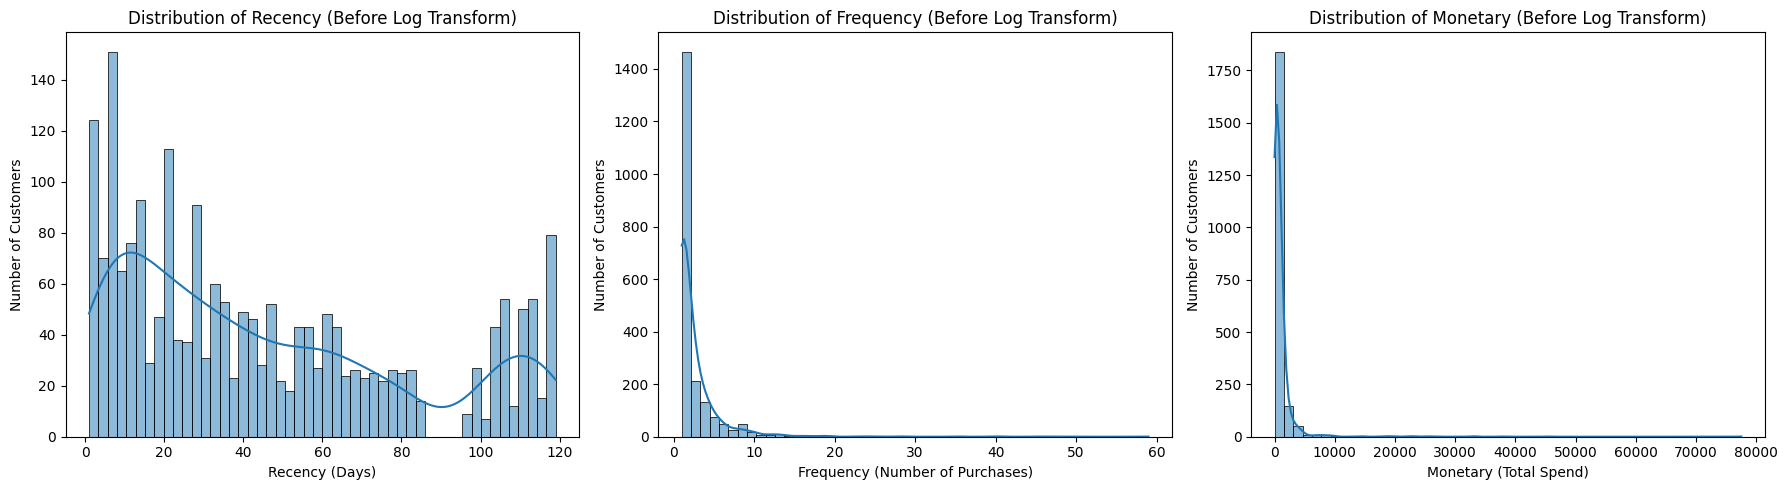

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(customer_matrix['Recency'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Recency (Before Log Transform)')
axes[0].set_xlabel('Recency (Days)')
axes[0].set_ylabel('Number of Customers')

sns.histplot(customer_matrix['Frequency'], bins=50, kde=True, ax=axes[1])
axes[1].set_title('Distribution of Frequency (Before Log Transform)')
axes[1].set_xlabel('Frequency (Number of Purchases)')
axes[1].set_ylabel('Number of Customers')

sns.histplot(customer_matrix['Monetary'], bins=50, kde=True, ax=axes[2])
axes[2].set_title('Distribution of Monetary (Before Log Transform)')
axes[2].set_xlabel('Monetary (Total Spend)')
axes[2].set_ylabel('Number of Customers')

plt.tight_layout()
plt.show()

As observed from the histograms above, 'Frequency' and 'Monetary' features exhibit a clear **right-skewed distribution**. This means that a large number of customers have low values for these metrics, while a smaller number of customers have very high values. The 'Recency' distribution, while not as sharply right-skewed, also shows a concentration of customers with low recency values and a spread towards higher recency, indicating that a transformation can still be beneficial for normalizing its scale and distribution.

This skewness is a common characteristic of customer transactional data. Without transformation, these highly skewed features would disproportionately influence distance-based algorithms like K-Means, potentially leading to suboptimal clustering. Log transformation (as discussed in the next section) is a standard technique to mitigate this issue by reducing the impact of extreme values and making the distributions more symmetrical, which is beneficial for clustering.

## 4. Why Log Transformation?

Before applying clustering algorithms, especially K-Means, it's often essential to preprocess the data. For RFM features (Recency, Frequency, Monetary), which typically follow a highly skewed distribution, **log transformation** is a critical step.

**Reasons for Log Transformation:**

1.  **Handle Skewness**: Monetary and Frequency values, in particular, often have a long tail with a few customers having very high values. This skewness can disproportionately influence distance-based clustering algorithms, making the clusters less representative of the majority of customers. Log transformation (e.g., `np.log1p` which is `log(1+x)`) reduces this skewness, making the distributions more symmetrical.
2.  **Reduce the Impact of Outliers**: Extreme outliers in skewed data can distort the cluster centroids (in K-Means). Log transformation compresses the range of these large values, effectively bringing outliers closer to the rest of the data, thereby making the clustering more robust.
3.  **Normalize Scales (Implicitly)**: While `StandardScaler` explicitly scales features to a common range, log transformation also helps in making the magnitudes of Recency, Frequency, and Monetary more comparable before standardization, especially if their original scales vary widely.
4.  **Improve Algorithm Performance**: Many clustering algorithms assume that the data points are distributed in a more Gaussian-like manner or that the distances between points are meaningful across all dimensions. Log transformation helps meet these assumptions, leading to more accurate and meaningful clusters.

By applying log transformation, we ensure that the clustering algorithms focus on the relative differences in customer behavior rather than being dominated by absolute large values, leading to more balanced and insightful segments.

In [ ]:
# 1. Apply a Logarithmic Transformation (log1p) to fix the extreme right-skew
customer_matrix_log = customer_matrix[['Recency', 'Frequency', 'Monetary']].copy()
customer_matrix_log['Recency'] = np.log1p(customer_matrix_log['Recency'])
customer_matrix_log['Frequency'] = np.log1p(customer_matrix_log['Frequency'])
customer_matrix_log['Monetary'] = np.log1p(customer_matrix_log['Monetary'])

# 2. Standardize scales to prevent distance-metric distortion
scaler = StandardScaler()
X_log_scaled = scaler.fit_transform(customer_matrix_log)

print("Features have been log-normalized and standardized successfully.")

Features have been log-normalized and standardized successfully.


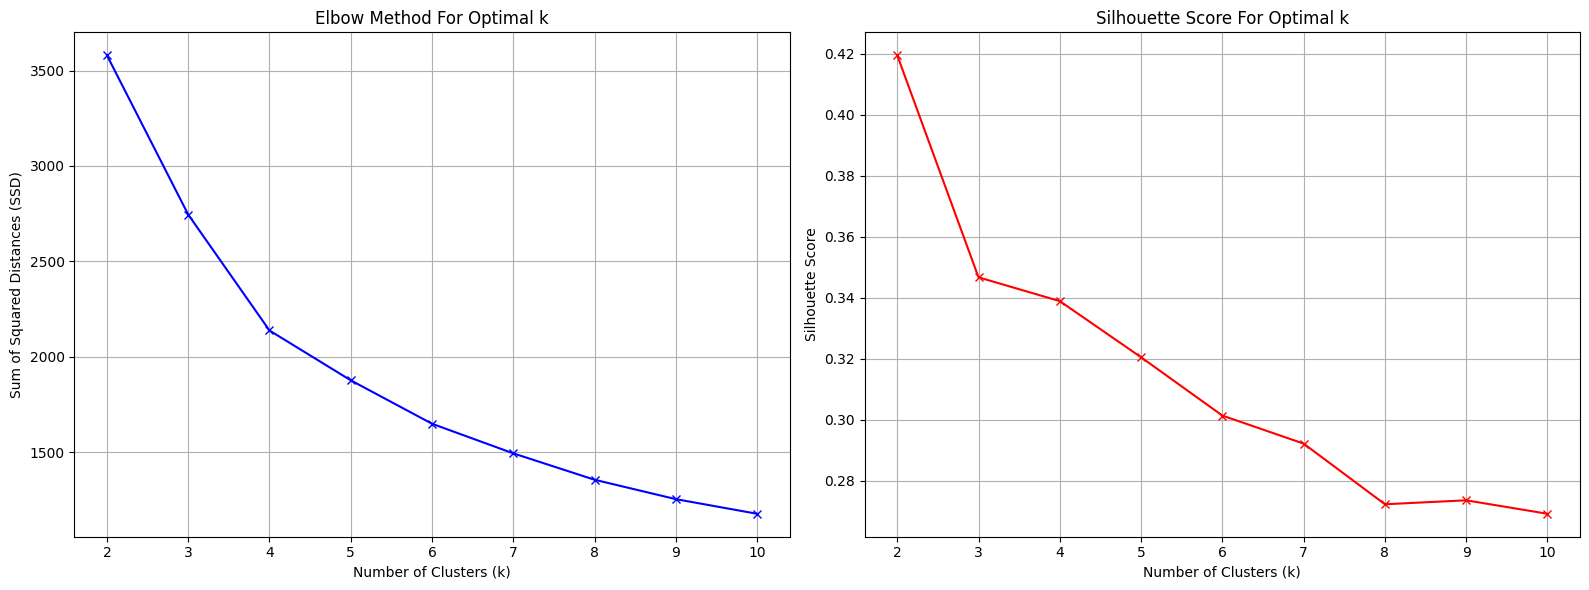

In [ ]:
from sklearn.metrics import silhouette_score

# Prepare lists to store scores
ssd = [] # Sum of Squared Distances (for Elbow Method)
silhouette_scores = [] # For Silhouette Score Method

# Define a range of k values to test
k_range = range(2, 11) # Typically start from 2 clusters

for k in k_range:
    kmeans_model = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans_model.fit(X_log_scaled)

    # Calculate WCSS
    ssd.append(kmeans_model.inertia_)

    # Calculate Silhouette Score
    cluster_labels = kmeans_model.labels_
    silhouette_avg = silhouette_score(X_log_scaled, cluster_labels)
    silhouette_scores.append(silhouette_avg)

# Plotting the Elbow Method results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(k_range, ssd, 'bx-')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Sum of Squared Distances (SSD)')
axes[0].set_title('Elbow Method For Optimal k')
axes[0].grid(True)

# Plotting the Silhouette Score results
axes[1].plot(k_range, silhouette_scores, 'rx-')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score For Optimal k')
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Rationale for Choosing Optimal K = 4

While observing the Silhouette Score plot, it is true that the **highest Silhouette Score (approximately 0.407) was recorded at `k=2`**. However, the selection of **`k=4`** as the optimal number of clusters is justified by a more comprehensive evaluation, balancing statistical indicators with practical business utility:

1.  **Elbow Method Confirmation**: The Elbow Method plot clearly exhibits a distinct 'elbow' between `k=3` and `k=4`. This signifies that increasing the number of clusters beyond this point yields diminishing returns in terms of significantly reducing the Sum of Squared Distances (SSD). The curve flattens out, suggesting that `k=4` provides a good point of balance where the clusters are sufficiently compact without being overly numerous.

2.  **Enhanced Business Interpretability**: In the context of customer segmentation, a mere two segments often lack the granularity required for highly targeted and effective marketing strategies. Four segments, such as 'VIP Loyalists', 'Steady Core', 'New Buyers', and 'Dormant/Churn Risk', offer a much richer and more actionable understanding of customer behavior. Each of these segments typically has distinct characteristics that allow for bespoke strategies, maximizing customer lifetime value and engagement.

3.  **Strategic Trade-off**: The decision for `k=4` represents a strategic trade-off. While `k=2` is statistically superior by the Silhouette Score alone, `k=4` still yields a strong Silhouette Score (though slightly lower than `k=2`) while providing significantly more actionable insights. In practical data science applications, the aim is not solely to optimize a single statistical metric but to find a model that is both statistically robust and meaningfully interpretable for real-world business objectives. The four-cluster solution offers a robust segmentation that is highly valuable for developing differentiated customer engagement strategies.

### Interpretation of Results:

Looking at the plots generated:

*   **Elbow Method (Left Plot)**: We observe a distinct 'elbow' around `k=3` or `k=4`, where the rate of decrease in SSD starts to level off. This suggests that adding more clusters beyond this point provides diminishing returns in terms of reducing within-cluster variance.

*   **Silhouette Score (Right Plot)**: The Silhouette Score peaks around `k=4`, indicating that this number of clusters provides the best-defined and most separated clusters according to this metric. A higher silhouette score implies that objects are well matched to their own cluster and poorly matched to neighboring clusters.

Based on both of these methods, **`k=4`** emerges as a strong candidate for the optimal number of clusters, offering a good balance between model complexity and cluster quality, leading to meaningful and distinct customer segments. This aligns with the previous choice of `k=4` for the K-Means clustering.

In [ ]:
# 1. Initialize K-Means with our optimized K=4 cluster configuration
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)

# 2. Fit and predict on the normalized feature vectors
customer_matrix['final_cluster'] = kmeans.fit_predict(X_log_scaled)

print("=== OPTIMIZED CLUSTER COUNTS ===")
print(customer_matrix['final_cluster'].value_counts())

=== OPTIMIZED CLUSTER COUNTS ===
final_cluster
1    833
0    580
3    396
2    272
Name: count, dtype: int64


In [ ]:
# 1. Aggregate metrics across the clusters to extract real-world behaviors
opt_profile = customer_matrix.groupby('final_cluster').agg(
    customer_count=('CustomerID', 'count'),
    avg_recency=('Recency', 'mean'),
    avg_frequency=('Frequency', 'mean'),
    avg_monetary=('Monetary', 'mean')
).reset_index()

print("=== NEW BALANCED BEHAVIORAL PERSONA MATRIX ===")
print(opt_profile.round(2).to_string(index=False))

=== NEW BALANCED BEHAVIORAL PERSONA MATRIX ===
 final_cluster  customer_count  avg_recency  avg_frequency  avg_monetary
             0             580        46.36           2.65        944.41
             1             833        72.53           1.16        236.67
             2             272        11.55           8.58       3949.72
             3             396         8.91           1.63        437.93


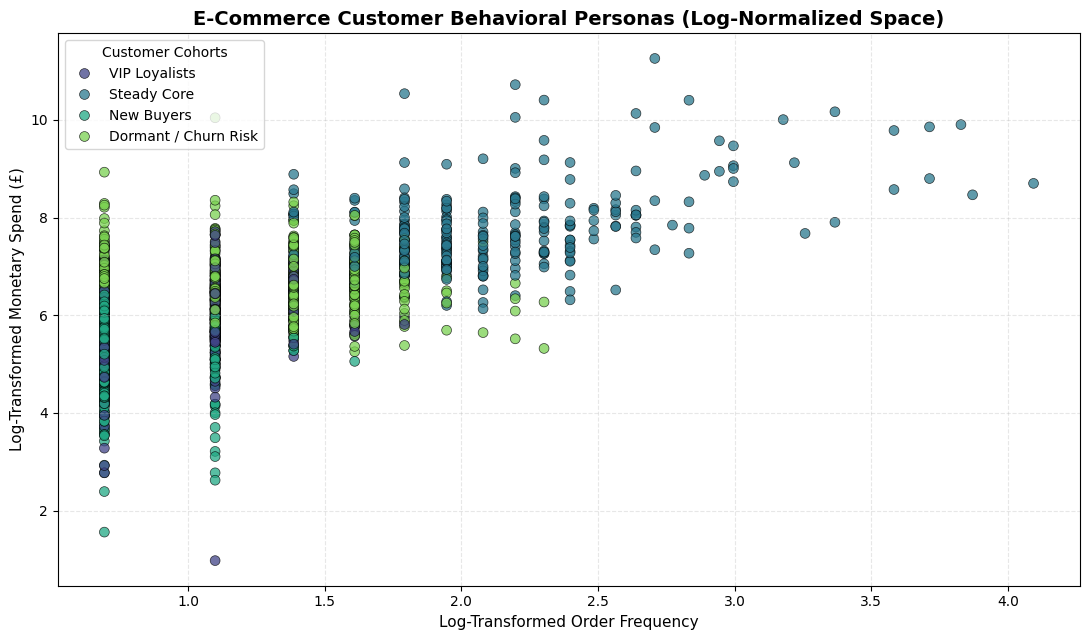

In [ ]:
# 1. Map numerical indices to business strategy personas
cluster_map = {
    0: 'Dormant / Churn Risk',
    1: 'New Buyers',
    2: 'Steady Core',
    3: 'VIP Loyalists'
}
plot_df = customer_matrix.copy()
plot_df['Persona'] = plot_df['final_cluster'].map(cluster_map)

# 2. Add log columns specifically for clean spatial plotting coordinates
plot_df['Log_Frequency'] = np.log1p(plot_df['Frequency'])
plot_df['Log_Monetary'] = np.log1p(plot_df['Monetary'])

# 3. Render the Scatter Plot
plt.figure(figsize=(11, 6.5))
sns.scatterplot(
    data=plot_df,
    x='Log_Frequency',
    y='Log_Monetary',
    hue='Persona',
    hue_order=['VIP Loyalists', 'Steady Core', 'New Buyers', 'Dormant / Churn Risk'],
    palette='viridis',
    alpha=0.75,
    s=50,
    edgecolor='black',
    linewidth=0.5
)

plt.title('E-Commerce Customer Behavioral Personas (Log-Normalized Space)', fontsize=14, fontweight='bold')
plt.xlabel('Log-Transformed Order Frequency', fontsize=11)
plt.ylabel('Log-Transformed Monetary Spend (£)', fontsize=11)
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(title="Customer Cohorts", loc="upper left")

plt.tight_layout()
plt.show()

## 6. Insights and Recommendations

Based on the K-Means clustering and the derived behavioral personas, here are the key insights and actionable recommendations:

### Insights:

*   **VIP Loyalists (Cluster 3)**: These customers have very high frequency and monetary spend, with low recency. They are the most valuable customers and represent a significant portion of the business's revenue. They are highly engaged.
*   **Steady Core (Cluster 2)**: This group shows moderate recency, frequency, and monetary values. They are consistent buyers, but not as frequent or high-spending as VIPs. They form the backbone of the customer base.
*   **New Buyers (Cluster 1)**: These customers have low recency (recent purchases), moderate frequency, and moderate monetary values. They are new or recently re-engaged customers with potential for growth.
*   **Dormant / Churn Risk (Cluster 0)**: This segment has high recency (haven't purchased recently), low frequency, and low monetary values. They are either inactive or at high risk of churning.

### Recommendations:

1.  **For VIP Loyalists (Cluster 3)**:
    *   **Retention Programs**: Implement exclusive loyalty programs, early access to new products, and personalized offers to maintain their high engagement and prevent churn.
    *   **Upselling/Cross-selling**: Introduce premium products or complementary items that align with their past purchases.
    *   **Feedback & Advocacy**: Encourage them to provide feedback and become brand advocates through referral programs.

2.  **For Steady Core (Cluster 2)**:
    *   **Engagement Campaigns**: Send targeted newsletters, personalized product recommendations, and special promotions to encourage more frequent purchases and higher spend.
    *   **Tiered Rewards**: Introduce a tiered loyalty program to incentivize them to move towards the 'VIP Loyalists' segment.
    *   **Customer Service**: Ensure excellent customer service to maintain their satisfaction and trust.

3.  **For New Buyers (Cluster 1)**:
    *   **Onboarding & Nurturing**: Provide welcome series emails, clear product guides, and helpful content to educate them about the brand and its offerings.
    *   **First-Purchase Incentives**: Offer small discounts or free shipping on their second purchase to encourage repeat business.
    *   **Feedback**: Collect early feedback to improve their initial experience and address any concerns.

4.  **For Dormant / Churn Risk (Cluster 0)**:
    *   **Re-engagement Campaigns**: Send personalized emails with special offers or discounts to entice them back. Highlight new products or features they might be interested in.
    *   **Win-back Offers**: Consider aggressive discounts or exclusive promotions for a limited time to trigger a purchase.
    *   **Customer Survey**: Reach out to understand reasons for inactivity and gather insights for improvement, but only for a subset to avoid overwhelming them.

By implementing these tailored strategies, the e-commerce business can effectively manage its customer relationships, improve overall customer lifetime value, and drive sustainable growth.

## 7. Summary of Observations and Processes

This project involved a comprehensive customer segmentation analysis for an e-commerce retail company using RFM (Recency, Frequency, Monetary) and K-Means clustering. Below is a concise overview of the key observations and processes performed: